In [1]:
import pandas as pd
import pygwalker as pyg

In [2]:
df = pd.read_csv('~/Downloads/social-media-engagement.csv')
df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


In [3]:
walker = pyg.walk(df)

Box(children=(HTML(value='\n<div id="ifr-pyg-00064fbcc19aad6ev6m91SMLwWnEkJUz" style="height: auto">\n    <hea…

In [4]:
from collections import Counter

hashtag_series = df['hashtags'].dropna().str.split(',').explode().str.strip()
hashtag_counts = Counter(hashtag_series)
hashtag_df = pd.DataFrame(hashtag_counts.items(), columns=['hashtag', 'count']).sort_values('count', ascending=False).head(20)

walker2 = pyg.walk(hashtag_df)

Box(children=(HTML(value='\n<div id="ifr-pyg-00064fbcc1a1ce4eYV2hr1m0WNzDX8wT" style="height: auto">\n    <hea…

In [5]:
top_20_hashtags = hashtag_df['hashtag'].tolist()

hashtag_geo = df[['hashtags', 'location', 'language']].copy()
hashtag_geo = hashtag_geo.dropna(subset=['hashtags'])
hashtag_geo = hashtag_geo.assign(hashtag=hashtag_geo['hashtags'].str.split(',')).explode('hashtag')
hashtag_geo['hashtag'] = hashtag_geo['hashtag'].str.strip()
hashtag_geo = hashtag_geo[hashtag_geo['hashtag'].isin(top_20_hashtags)]

walker3 = pyg.walk(hashtag_geo)

Box(children=(HTML(value='\n<div id="ifr-pyg-00064fbcc1a3c091tabf78JTIlr2iXKL" style="height: auto">\n    <hea…

In [6]:
from itertools import combinations
from collections import Counter

df['hashtag_list'] = df['hashtags'].str.split(',').apply(
    lambda tags: [t.strip() for t in tags]
)

all_hashtags = [tag for tags in df['hashtag_list'] for tag in tags]
hashtag_freq = Counter(all_hashtags)

print("Total unique hashtags:", len(hashtag_freq))
print("\nTop 20 by frequency:")
for tag, count in hashtag_freq.most_common(20):
    print(f"  {tag}: {count}")

pair_counts = Counter()
for tags in df['hashtag_list']:
    if len(tags) >= 2:
        for pair in combinations(sorted(tags), 2):
            pair_counts[pair] += 1

print("\nTotal unique co-occurrence pairs:", len(pair_counts))
print("\nTop 20 most common pairs:")
for pair, count in pair_counts.most_common(20):
    print(f"  {pair}: {count}")

Total unique hashtags: 29

Top 20 by frequency:
  #Fitness: 885
  #Reviews: 884
  #BestValue: 870
  #SpecialOffer: 849
  #Promo: 847
  #Fashion: 846
  #Trending: 845
  #Health: 845
  #Premium: 845
  #Sustainable: 844
  #MustHave: 843
  #Affordable: 842
  #Beauty: 835
  #Deal: 833
  #TrendAlert: 833
  #Lifestyle: 832
  #Eco: 831
  #Travel: 830
  #NewRelease: 819
  #Food: 817

Total unique co-occurrence pairs: 406

Top 20 most common pairs:
  ('#Eco', '#Promo'): 60
  ('#Affordable', '#Premium'): 59
  ('#Reviews', '#Sale'): 57
  ('#Lifestyle', '#Premium'): 57
  ('#Health', '#Reviews'): 56
  ('#Food', '#SpecialOffer'): 56
  ('#Affordable', '#SpecialOffer'): 55
  ('#BestValue', '#Tech'): 54
  ('#Beauty', '#Reviews'): 54
  ('#BestValue', '#Premium'): 54
  ('#MustHave', '#Sustainable'): 54
  ('#Food', '#Reviews'): 53
  ('#Beauty', '#Deal'): 52
  ('#Health', '#TrendAlert'): 52
  ('#Premium', '#Quality'): 52
  ('#BestValue', '#Limited'): 51
  ('#Health', '#MustHave'): 51
  ('#Fitness', '#Sale')

In [7]:
import networkx as nx

G = nx.Graph()

for tag, freq in hashtag_freq.items():
    G.add_node(tag, frequency=freq)

for (tag1, tag2), count in pair_counts.items():
    G.add_edge(tag1, tag2, weight=count)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Is connected:", nx.is_connected(G))
print("Average degree:", round(sum(dict(G.degree()).values()) / G.number_of_nodes(), 2))
print("\nDegree of each node (how many other hashtags it co-occurs with):")
for node, degree in sorted(G.degree(), key=lambda x: x[1], reverse=True):
    print(f"  {node}: {degree}")

Nodes: 29
Edges: 406
Is connected: True
Average degree: 28.0

Degree of each node (how many other hashtags it co-occurs with):
  #Food: 28
  #MustHave: 28
  #Promo: 28
  #Trending: 28
  #Reviews: 28
  #Sustainable: 28
  #Health: 28
  #Travel: 28
  #Discount: 28
  #Quality: 28
  #Limited: 28
  #Deal: 28
  #Fashion: 28
  #Tech: 28
  #SpecialOffer: 28
  #Eco: 28
  #Lifestyle: 28
  #Fitness: 28
  #ProductLaunch: 28
  #Premium: 28
  #Affordable: 28
  #BestValue: 28
  #Innovation: 28
  #TrendAlert: 28
  #Sale: 28
  #Beauty: 28
  #NewRelease: 28
  #CustomerService: 28
  #Exclusive: 28


In [8]:
degree_centrality = nx.degree_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, weight='weight')
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

import pandas as pd

metrics_df = pd.DataFrame({
    'hashtag': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'eigenvector_centrality': list(eigenvector_centrality.values()),
    'betweenness_centrality': list(betweenness_centrality.values()),
    'frequency': [hashtag_freq[tag] for tag in degree_centrality.keys()]
})

metrics_df = metrics_df.sort_values('eigenvector_centrality', ascending=False).reset_index(drop=True)

print(metrics_df.to_string())

             hashtag  degree_centrality  eigenvector_centrality  betweenness_centrality  frequency
0      #SpecialOffer                1.0                0.198615                0.000000        849
1           #Fitness                1.0                0.196933                0.000000        885
2         #BestValue                1.0                0.196198                0.000000        870
3           #Reviews                1.0                0.195232                0.000000        884
4           #Fashion                1.0                0.194645                0.000000        846
5        #Affordable                1.0                0.194270                0.000000        842
6             #Promo                1.0                0.191499                0.000000        847
7          #MustHave                1.0                0.190988                0.000000        843
8       #Sustainable                1.0                0.190755                0.000000        844
9         

In [9]:
import community as community_louvain

partition = community_louvain.best_partition(G, weight='weight', random_state=42)

metrics_df['community'] = metrics_df['hashtag'].map(partition)

print("Community assignments:")
for comm_id in sorted(set(partition.values())):
    members = [tag for tag, c in partition.items() if c == comm_id]
    print(f"\n  Community {comm_id} ({len(members)} hashtags):")
    for tag in members:
        print(f"    {tag}")

modularity = community_louvain.modularity(partition, G, weight='weight')
print(f"\nModularity score: {modularity:.4f}")
print("(Note: scores near 0 indicate weak community structure)")

Community assignments:

  Community 0 (29 hashtags):
    #Food
    #MustHave
    #Promo
    #Trending
    #Reviews
    #Sustainable
    #Health
    #Travel
    #Discount
    #Quality
    #Limited
    #Deal
    #Fashion
    #Tech
    #SpecialOffer
    #Eco
    #Lifestyle
    #Fitness
    #ProductLaunch
    #Premium
    #Affordable
    #BestValue
    #Innovation
    #TrendAlert
    #Sale
    #Beauty
    #NewRelease
    #CustomerService
    #Exclusive

Modularity score: 0.0000
(Note: scores near 0 indicate weak community structure)


In [10]:
hashtag_engagement = df[['hashtag_list', 'engagement_rate', 'sentiment_score', 
                          'likes_count', 'shares_count', 'platform', 'location', 
                          'language']].explode('hashtag_list')
hashtag_engagement = hashtag_engagement.rename(columns={'hashtag_list': 'hashtag'})

hashtag_agg = hashtag_engagement.groupby('hashtag').agg(
    avg_engagement_rate=('engagement_rate', 'mean'),
    avg_sentiment=('sentiment_score', 'mean'),
    avg_likes=('likes_count', 'mean'),
    avg_shares=('shares_count', 'mean'),
    post_count=('engagement_rate', 'count')
).reset_index()

enriched_df = metrics_df.merge(hashtag_agg, on='hashtag')

enriched_df = enriched_df.sort_values('avg_engagement_rate', ascending=False).reset_index(drop=True)

print(enriched_df[['hashtag', 'eigenvector_centrality', 'avg_engagement_rate', 
                    'avg_sentiment', 'avg_likes', 'post_count']].to_string())

             hashtag  eigenvector_centrality  avg_engagement_rate  avg_sentiment    avg_likes  post_count
0              #Food                0.178252             0.373036      -0.008872  2571.932681         817
1         #Lifestyle                0.183732             0.351806      -0.002634  2518.662260         832
2        #NewRelease                0.176599             0.343599       0.006998  2458.614164         819
3          #Trending                0.188523             0.341674      -0.003749  2517.671006         845
4              #Tech                0.180612             0.337387       0.018940  2412.431204         814
5           #Fitness                0.196933             0.335482       0.013595  2424.341243         885
6            #Beauty                0.182494             0.312093      -0.008074  2575.217964         835
7       #Sustainable                0.190755             0.297669      -0.035332  2525.450237         844
8            #Travel                0.183969  

In [11]:
from scipy import stats

r, p = stats.pearsonr(enriched_df['eigenvector_centrality'], 
                       enriched_df['avg_engagement_rate'])

print(f"Pearson r (eigenvector vs engagement): {r:.4f}")
print(f"P-value: {p:.4f}")
print(f"Interpretation: {'significant' if p < 0.05 else 'not significant'} correlation")

r2, p2 = stats.pearsonr(enriched_df['frequency'], 
                         enriched_df['avg_engagement_rate'])
print(f"\nPearson r (frequency vs engagement): {r2:.4f}")
print(f"P-value: {p2:.4f}")
print(f"Interpretation: {'significant' if p2 < 0.05 else 'not significant'} correlation")

Pearson r (eigenvector vs engagement): -0.0771
P-value: 0.6912
Interpretation: not significant correlation

Pearson r (frequency vs engagement): 0.1454
P-value: 0.4518
Interpretation: not significant correlation


In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

pos = nx.spring_layout(G, weight='weight', seed=42, k=2)

node_sizes = [hashtag_freq[node] * 0.8 for node in G.nodes()]

eig_values = [eigenvector_centrality[node] for node in G.nodes()]
norm = mcolors.Normalize(vmin=min(eig_values), vmax=max(eig_values))
cmap = cm.RdYlGn
node_colors = [cmap(norm(v)) for v in eig_values]

edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_w = max(edge_weights)
edge_widths = [w / max_w * 2.5 for w in edge_weights]

edge_colors = ['#cccccc'] * len(G.edges())

fig, ax = plt.subplots(figsize=(18, 14))

nx.draw_networkx_edges(G, pos, width=edge_widths, 
                        edge_color=edge_colors, alpha=0.4, ax=ax)

nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                        node_color=node_colors, alpha=0.9, ax=ax)

nx.draw_networkx_labels(G, pos, font_size=8, 
                         font_weight='bold', ax=ax)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Eigenvector Centrality', shrink=0.6)

ax.set_title('Hashtag Co-occurrence Network\n(Node size = frequency, '
             'Node color = eigenvector centrality, '
             'Edge width = co-occurrence strength)',
             fontsize=13, pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig('hashtag_network.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hashtag_network.png")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ax1 = axes[0, 0]
sorted_eig = enriched_df.sort_values('eigenvector_centrality', ascending=True)
colors_eig = [cmap(norm(v)) for v in sorted_eig['eigenvector_centrality']]
ax1.barh(sorted_eig['hashtag'], sorted_eig['eigenvector_centrality'],
         color=colors_eig, edgecolor='white')
ax1.set_title('Hashtags by Eigenvector Centrality', fontsize=12, fontweight='bold')
ax1.set_xlabel('Eigenvector Centrality')
ax1.tick_params(axis='y', labelsize=8)
ax1.grid(True, axis='x', alpha=0.3)

ax2 = axes[0, 1]
sorted_eng = enriched_df.sort_values('avg_engagement_rate', ascending=True)
norm_eng = mcolors.Normalize(vmin=sorted_eng['avg_engagement_rate'].min(),
                              vmax=sorted_eng['avg_engagement_rate'].max())
colors_eng = [cmap(norm_eng(v)) for v in sorted_eng['avg_engagement_rate']]
ax2.barh(sorted_eng['hashtag'], sorted_eng['avg_engagement_rate'],
         color=colors_eng, edgecolor='white')
ax2.set_title('Hashtags by Average Engagement Rate', fontsize=12, fontweight='bold')
ax2.set_xlabel('Average Engagement Rate')
ax2.tick_params(axis='y', labelsize=8)
ax2.grid(True, axis='x', alpha=0.3)

ax3 = axes[1, 0]
scatter = ax3.scatter(enriched_df['eigenvector_centrality'],
                       enriched_df['avg_engagement_rate'],
                       c=enriched_df['frequency'],
                       cmap='viridis', s=150, alpha=0.8, edgecolors='white')
for _, row in enriched_df.iterrows():
    ax3.annotate(row['hashtag'],
                 (row['eigenvector_centrality'], row['avg_engagement_rate']),
                 fontsize=6, ha='left', va='bottom',
                 xytext=(3, 3), textcoords='offset points')
plt.colorbar(scatter, ax=ax3, label='Hashtag Frequency')
ax3.set_title('Eigenvector Centrality vs Engagement Rate\n(color = frequency)',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Eigenvector Centrality')
ax3.set_ylabel('Average Engagement Rate')
ax3.grid(True, alpha=0.3)

ax3.annotate(f'r = -0.077, p = 0.691 (not significant)',
             xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=9, color='grey',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax4 = axes[1, 1]
hashtag_list_sorted = enriched_df['hashtag'].tolist()
matrix = np.zeros((len(hashtag_list_sorted), len(hashtag_list_sorted)))
for (t1, t2), w in pair_counts.items():
    if t1 in hashtag_list_sorted and t2 in hashtag_list_sorted:
        i = hashtag_list_sorted.index(t1)
        j = hashtag_list_sorted.index(t2)
        matrix[i, j] = w
        matrix[j, i] = w

import seaborn as sns
sns.heatmap(matrix, ax=ax4,
            xticklabels=hashtag_list_sorted,
            yticklabels=hashtag_list_sorted,
            cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Co-occurrence Count'})
ax4.set_title('Hashtag Co-occurrence Heatmap', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=90, labelsize=6)
ax4.tick_params(axis='y', rotation=0, labelsize=6)

plt.suptitle('SMAHR Framework — Hashtag Network Analysis\nSocial Media Engagement Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('hashtag_analysis_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hashtag_analysis_panel.png")

Saved: hashtag_network.png
Saved: hashtag_analysis_panel.png


In [13]:
# solving subproblem 1 from problem def

hashtag_engagement = df[['hashtag_list', 'engagement_rate', 'likes_count', 
                          'shares_count', 'comments_count']].explode('hashtag_list')
hashtag_engagement = hashtag_engagement.rename(columns={'hashtag_list': 'hashtag'})

hashtag_agg_sum = hashtag_engagement.groupby('hashtag').agg(
    total_likes=('likes_count', 'sum'),
    total_shares=('shares_count', 'sum'),
    total_comments=('comments_count', 'sum'),
    post_count=('engagement_rate', 'count')
).reset_index()

hashtag_agg_sum['total_interactions'] = (
    hashtag_agg_sum['total_likes'] +
    hashtag_agg_sum['total_shares'] +
    hashtag_agg_sum['total_comments']
)

hashtag_agg_sum = hashtag_agg_sum.sort_values(
    'total_interactions', ascending=False
).reset_index(drop=True)

print(hashtag_agg_sum.to_string())

             hashtag  total_likes  total_shares  total_comments  post_count  total_interactions
0           #Reviews      2192578        878205          455504         884             3526287
1           #Fitness      2145542        916941          433493         885             3495976
2         #BestValue      2175631        870683          442514         870             3488828
3          #Trending      2127432        854884          427267         845             3409583
4            #Health      2119417        858628          429910         845             3407955
5        #Affordable      2119632        862009          424854         842             3406495
6            #Travel      2133525        851705          416481         830             3401711
7           #Premium      2119044        855314          424740         845             3399098
8       #Sustainable      2131480        843819          422916         844             3398215
9            #Beauty      2150307       

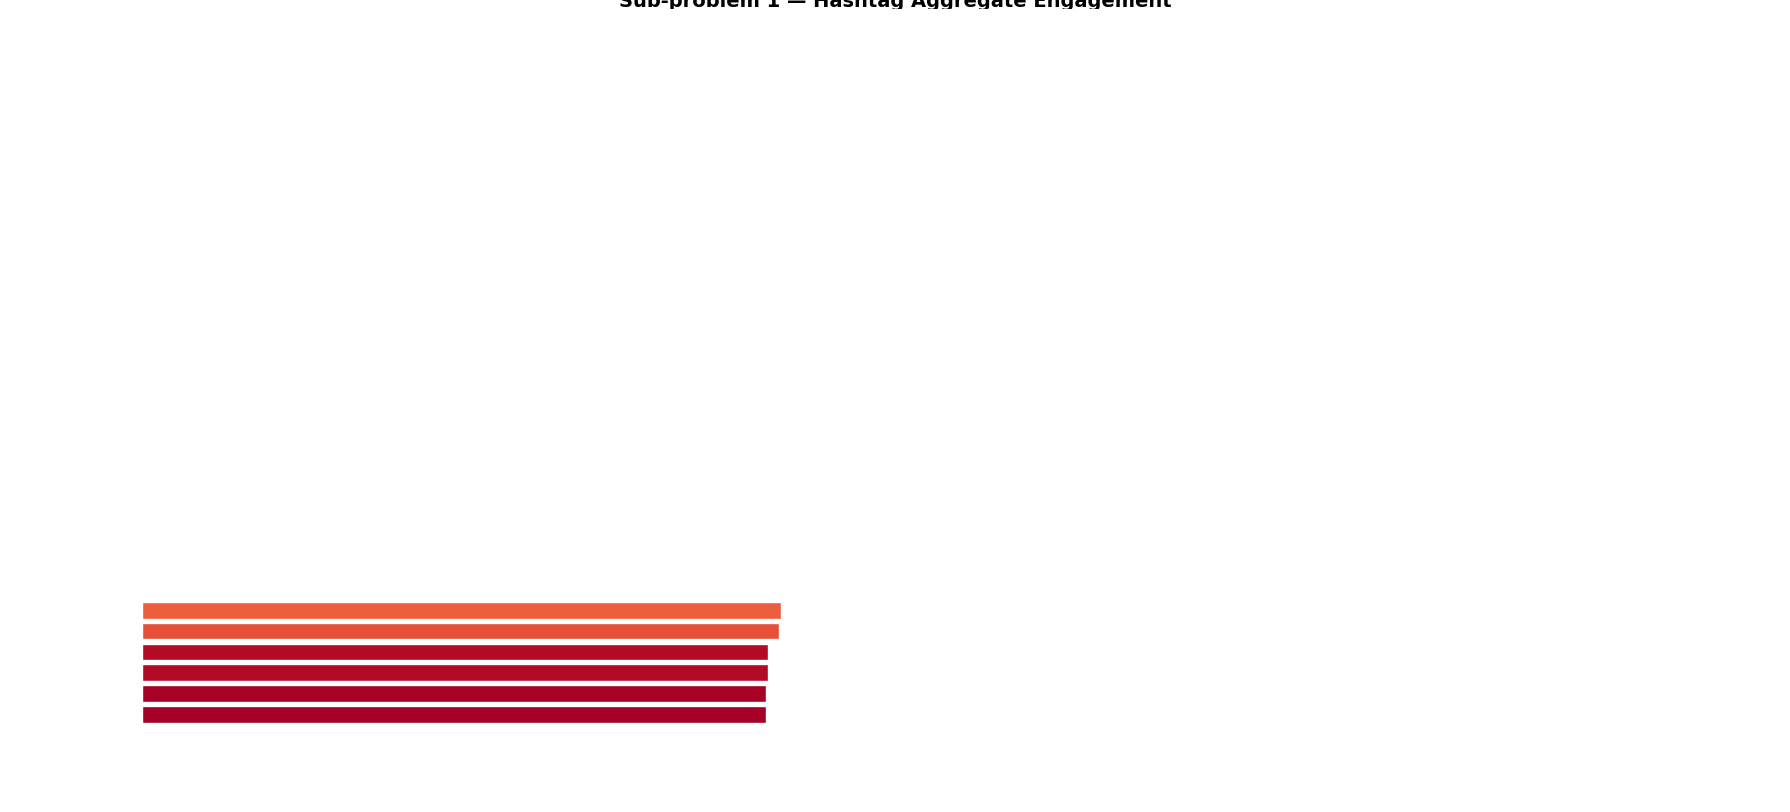

Saved: subproblem1_hashtag_engagement.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax1 = axes[0]
sorted_total = hashtag_agg_sum.sort_values('total_interactions', ascending=True)
norm_total = mcolors.Normalize(vmin=sorted_total['total_interactions'].min(),
                                vmax=sorted_total['total_interactions'].max())
colors_total = [cmap(norm_total(v)) for v in sorted_total['total_interactions']]
ax1.barh(sorted_total['hashtag'], sorted_total['total_interactions'],
         color=colors_total, edgecolor='white')
ax1.set_title('Total Aggregate Engagement per Hashtag\n(likes + shares + comments)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Interactions')
ax1.tick_params(axis='y', labelsize=9)
ax1.grid(True, axis='x', alpha=0.3)

ax2 = axes[1]
sorted_stack = hashtag_agg_sum.sort_values('total_interactions', ascending=True)
ax2.barh(sorted_stack['hashtag'], sorted_stack['total_likes'],
         label='Likes', color='#4C72B0', edgecolor='white')
ax2.barh(sorted_stack['hashtag'], sorted_stack['total_shares'],
         left=sorted_stack['total_likes'],
         label='Shares', color='#55A868', edgecolor='white')
ax2.barh(sorted_stack['hashtag'], sorted_stack['total_comments'],
         left=sorted_stack['total_likes'] + sorted_stack['total_shares'],
         label='Comments', color='#C44E52', edgecolor='white')
ax2.set_title('Engagement Breakdown per Hashtag\n(likes / shares / comments)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Total Interactions')
ax2.tick_params(axis='y', labelsize=9)
ax2.legend(loc='lower right')
ax2.grid(True, axis='x', alpha=0.3)

plt.suptitle('Sub-problem 1 — Hashtag Aggregate Engagement',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('subproblem1_hashtag_engagement.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: subproblem1_hashtag_engagement.png")

In [15]:
print("=" * 55)
print("SUB-PROBLEM 1 FINDINGS — Hashtag Aggregate Engagement")
print("=" * 55)

print(f"\nTop 5 hashtags by total interactions:")
for _, row in hashtag_agg_sum.head(5).iterrows():
    print(f"  {row['hashtag']:<20} {int(row['total_interactions']):>10,} interactions")

print(f"\nBottom 5 hashtags by total interactions:")
for _, row in hashtag_agg_sum.tail(5).iterrows():
    print(f"  {row['hashtag']:<20} {int(row['total_interactions']):>10,} interactions")

print(f"\nRange: {int(hashtag_agg_sum['total_interactions'].min()):,} "
      f"to {int(hashtag_agg_sum['total_interactions'].max()):,}")
print(f"Spread: {int(hashtag_agg_sum['total_interactions'].max() - hashtag_agg_sum['total_interactions'].min()):,}")

SUB-PROBLEM 1 FINDINGS — Hashtag Aggregate Engagement

Top 5 hashtags by total interactions:
  #Reviews              3,526,287 interactions
  #Fitness              3,495,976 interactions
  #BestValue            3,488,828 interactions
  #Trending             3,409,583 interactions
  #Health               3,407,955 interactions

Bottom 5 hashtags by total interactions:
  #Tech                 3,164,425 interactions
  #Exclusive            3,109,941 interactions
  #Discount             3,109,014 interactions
  #Limited              3,101,473 interactions
  #Innovation           3,098,363 interactions

Range: 3,098,363 to 3,526,287
Spread: 427,924


In [17]:
# subproblem 2

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['Hour'] = df['timestamp'].dt.hour
df['Month'] = df['timestamp'].dt.month

hashtag_temporal = df[['hashtag_list', 'engagement_rate',
                        'Hour', 'Month', 'day_of_week']].explode('hashtag_list')
hashtag_temporal = hashtag_temporal.rename(columns={'hashtag_list': 'hashtag'})

hashtag_hourly = hashtag_temporal.groupby(['hashtag', 'Hour'])['engagement_rate'].mean().reset_index()
hashtag_hourly.columns = ['hashtag', 'Hour', 'avg_engagement_rate']

hashtag_monthly = hashtag_temporal.groupby(['hashtag', 'Month'])['engagement_rate'].mean().reset_index()
hashtag_monthly.columns = ['hashtag', 'Month', 'avg_engagement_rate']

from scipy import stats as scipy_stats

trend_summary = []
for tag in hashtag_hourly['hashtag'].unique():
    subset = hashtag_hourly[hashtag_hourly['hashtag'] == tag].sort_values('Hour')
    slope, _, r_value, p_value, _ = scipy_stats.linregress(
        subset['Hour'], subset['avg_engagement_rate']
    )
    if p_value < 0.05:
        trend = 'Increasing' if slope > 0 else 'Decreasing'
    else:
        trend = 'Fluctuating'
    trend_summary.append({
        'hashtag': tag,
        'slope': slope,
        'r_squared': r_value**2,
        'p_value': p_value,
        'trend': trend
    })

trend_df = pd.DataFrame(trend_summary).sort_values('slope', ascending=False).reset_index(drop=True)
print(trend_df.to_string())

             hashtag     slope  r_squared   p_value        trend
0              #Food  0.018043   0.107106  0.118512  Fluctuating
1           #Fitness  0.013692   0.133567  0.079058  Fluctuating
2            #Health  0.008548   0.171057  0.044539   Increasing
3     #ProductLaunch  0.005191   0.072008  0.204856  Fluctuating
4        #Affordable  0.004654   0.040463  0.345925  Fluctuating
5           #Premium  0.003936   0.032995  0.395621  Fluctuating
6              #Sale  0.003804   0.052785  0.280150  Fluctuating
7               #Eco  0.003723   0.036265  0.372757  Fluctuating
8          #MustHave  0.003358   0.046452  0.311803  Fluctuating
9           #Limited  0.001451   0.005586  0.728520  Fluctuating
10          #Reviews  0.001446   0.002462  0.817906  Fluctuating
11          #Quality  0.000810   0.001941  0.838049  Fluctuating
12             #Deal  0.000658   0.002299  0.823922  Fluctuating
13        #BestValue -0.000496   0.000269  0.939350  Fluctuating
14            #Promo -0.0

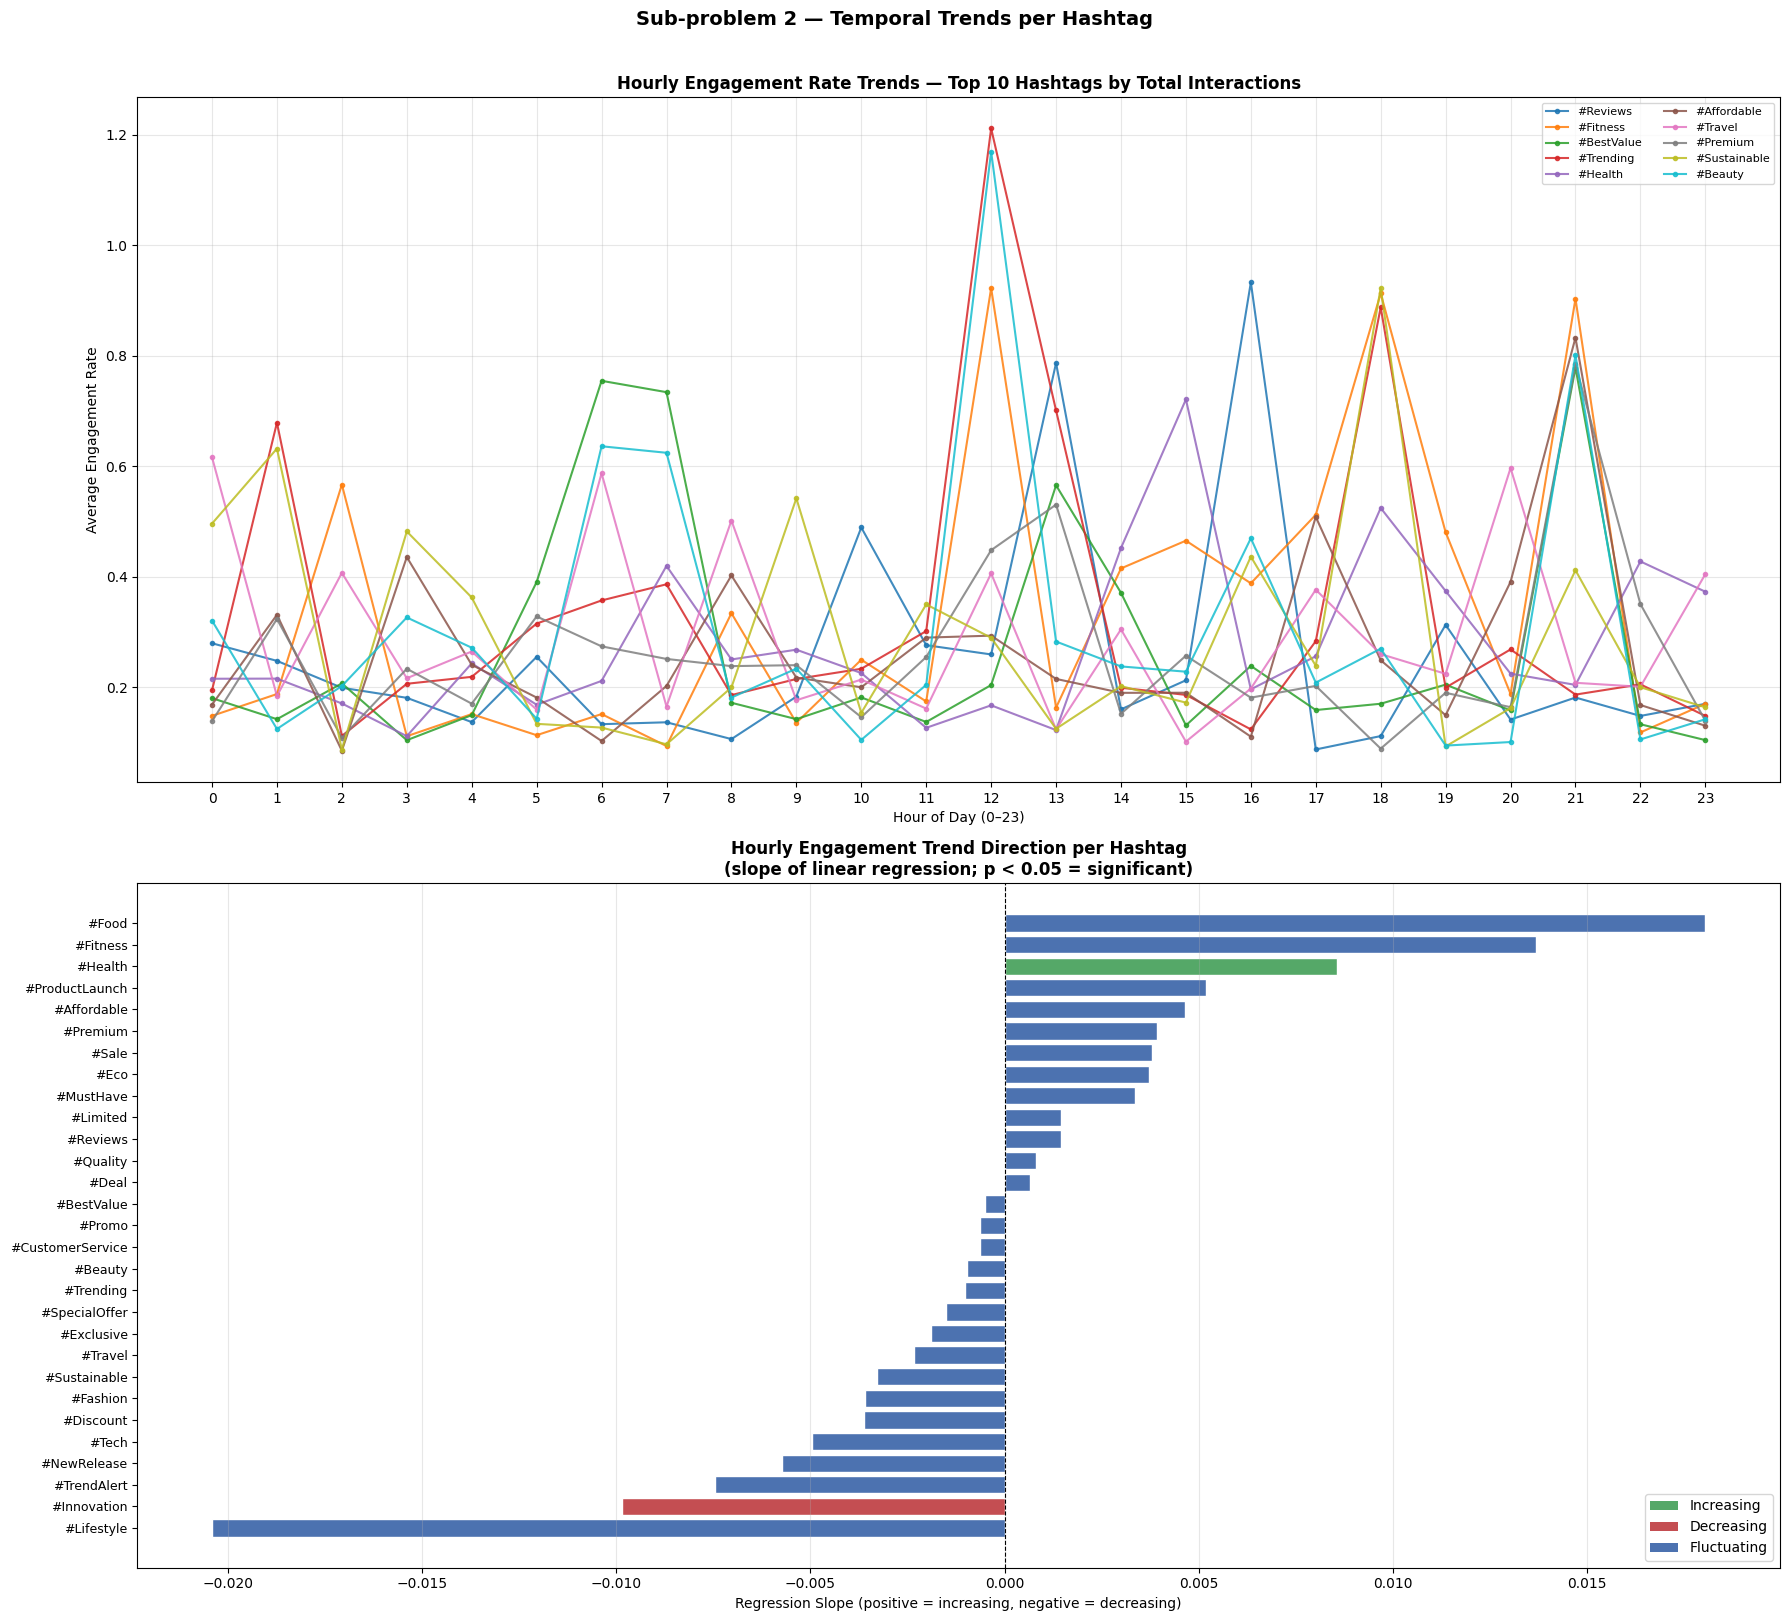

Saved: subproblem2_temporal_trends.png


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(18, 16))

ax1 = axes[0]
top10 = hashtag_agg_sum.head(10)['hashtag'].tolist()
palette = plt.cm.tab10.colors

for i, tag in enumerate(top10):
    subset = hashtag_hourly[hashtag_hourly['hashtag'] == tag].sort_values('Hour')
    ax1.plot(subset['Hour'], subset['avg_engagement_rate'],
             marker='o', markersize=3, linewidth=1.5,
             label=tag, color=palette[i], alpha=0.85)

ax1.set_title('Hourly Engagement Rate Trends — Top 10 Hashtags by Total Interactions',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Hour of Day (0–23)')
ax1.set_ylabel('Average Engagement Rate')
ax1.set_xticks(range(0, 24))
ax1.legend(loc='upper right', fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
trend_colors = {'Increasing': '#55A868', 'Decreasing': '#C44E52', 'Fluctuating': '#4C72B0'}
sorted_trend = trend_df.sort_values('slope', ascending=True)
bar_colors = [trend_colors[t] for t in sorted_trend['trend']]

bars = ax2.barh(sorted_trend['hashtag'], sorted_trend['slope'],
                color=bar_colors, edgecolor='white')
ax2.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Hourly Engagement Trend Direction per Hashtag\n(slope of linear regression; p < 0.05 = significant)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Regression Slope (positive = increasing, negative = decreasing)')
ax2.tick_params(axis='y', labelsize=9)
ax2.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in trend_colors.items()]
ax2.legend(handles=legend_elements, loc='lower right')

plt.suptitle('Sub-problem 2 — Temporal Trends per Hashtag',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('subproblem2_temporal_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: subproblem2_temporal_trends.png")

In [19]:
print("=" * 55)
print("SUB-PROBLEM 2 FINDINGS — Temporal Trends per Hashtag")
print("=" * 55)

for trend_type in ['Increasing', 'Decreasing', 'Fluctuating']:
    subset = trend_df[trend_df['trend'] == trend_type]
    print(f"\n{trend_type} ({len(subset)} hashtags):")
    for _, row in subset.iterrows():
        print(f"  {row['hashtag']:<20} slope={row['slope']:+.6f}  "
              f"p={row['p_value']:.4f}")

SUB-PROBLEM 2 FINDINGS — Temporal Trends per Hashtag

Increasing (1 hashtags):
  #Health              slope=+0.008548  p=0.0445

Decreasing (1 hashtags):
  #Innovation          slope=-0.009861  p=0.0361

Fluctuating (27 hashtags):
  #Food                slope=+0.018043  p=0.1185
  #Fitness             slope=+0.013692  p=0.0791
  #ProductLaunch       slope=+0.005191  p=0.2049
  #Affordable          slope=+0.004654  p=0.3459
  #Premium             slope=+0.003936  p=0.3956
  #Sale                slope=+0.003804  p=0.2802
  #Eco                 slope=+0.003723  p=0.3728
  #MustHave            slope=+0.003358  p=0.3118
  #Limited             slope=+0.001451  p=0.7285
  #Reviews             slope=+0.001446  p=0.8179
  #Quality             slope=+0.000810  p=0.8380
  #Deal                slope=+0.000658  p=0.8239
  #BestValue           slope=-0.000496  p=0.9394
  #Promo               slope=-0.000621  p=0.7992
  #CustomerService     slope=-0.000624  p=0.8575
  #Beauty              slope=-0.00

In [20]:
# subproblem 3

from scipy import stats as scipy_stats

platform_topic = df.groupby(['platform', 'topic_category'])['engagement_rate'].mean().reset_index()
platform_topic.columns = ['platform', 'topic_category', 'avg_engagement_rate']

platform_topic_pivot = platform_topic.pivot(
    index='topic_category', 
    columns='platform', 
    values='avg_engagement_rate'
)

print("Mean engagement rate by platform and topic category:")
print(platform_topic_pivot.round(4).to_string())

platform_means = df.groupby('platform')['engagement_rate'].mean().sort_values(ascending=False)
print("\nOverall mean engagement rate by platform:")
print(platform_means.round(4).to_string())

platform_groups = [group['engagement_rate'].values 
                   for _, group in df.groupby('platform')]
f_stat, p_value = scipy_stats.f_oneway(*platform_groups)
print(f"\nANOVA (engagement_rate ~ platform):")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Result: {'Significant' if p_value < 0.05 else 'Not significant'} "
      f"difference across platforms (α = 0.05)")

print("\nPer-topic ANOVA results:")
print(f"{'Topic':<25} {'F-stat':>10} {'P-value':>10} {'Significant':>12}")
print("-" * 60)
for topic in sorted(df['topic_category'].unique()):
    topic_df = df[df['topic_category'] == topic]
    groups = [g['engagement_rate'].values for _, g in topic_df.groupby('platform')]
    if all(len(g) > 1 for g in groups):
        f, p = scipy_stats.f_oneway(*groups)
        sig = 'Yes' if p < 0.05 else 'No'
        print(f"{topic:<25} {f:>10.4f} {p:>10.4f} {sig:>12}")

Mean engagement rate by platform and topic category:
platform        Facebook  Instagram  Reddit  Twitter  YouTube
topic_category                                               
Delivery          0.3579     0.2954  0.2704   0.3476   0.3357
Marketing         0.2396     0.2713  0.2648   0.2354   0.2141
Pricing           0.2351     0.3146  0.3366   0.2262   0.2876
Product           0.2969     0.2496  0.3142   0.2579   0.4069
Returns           0.3091     0.2993  0.2676   0.2312   0.2176
Support           0.2758     0.2863  0.2188   0.2554   0.2099

Overall mean engagement rate by platform:
platform
Instagram    0.2871
Facebook     0.2864
YouTube      0.2792
Reddit       0.2787
Twitter      0.2593

ANOVA (engagement_rate ~ platform):
  F-statistic: 0.2293
  P-value: 0.9221
  Result: Not significant difference across platforms (α = 0.05)

Per-topic ANOVA results:
Topic                         F-stat    P-value  Significant
------------------------------------------------------------
Delivery 

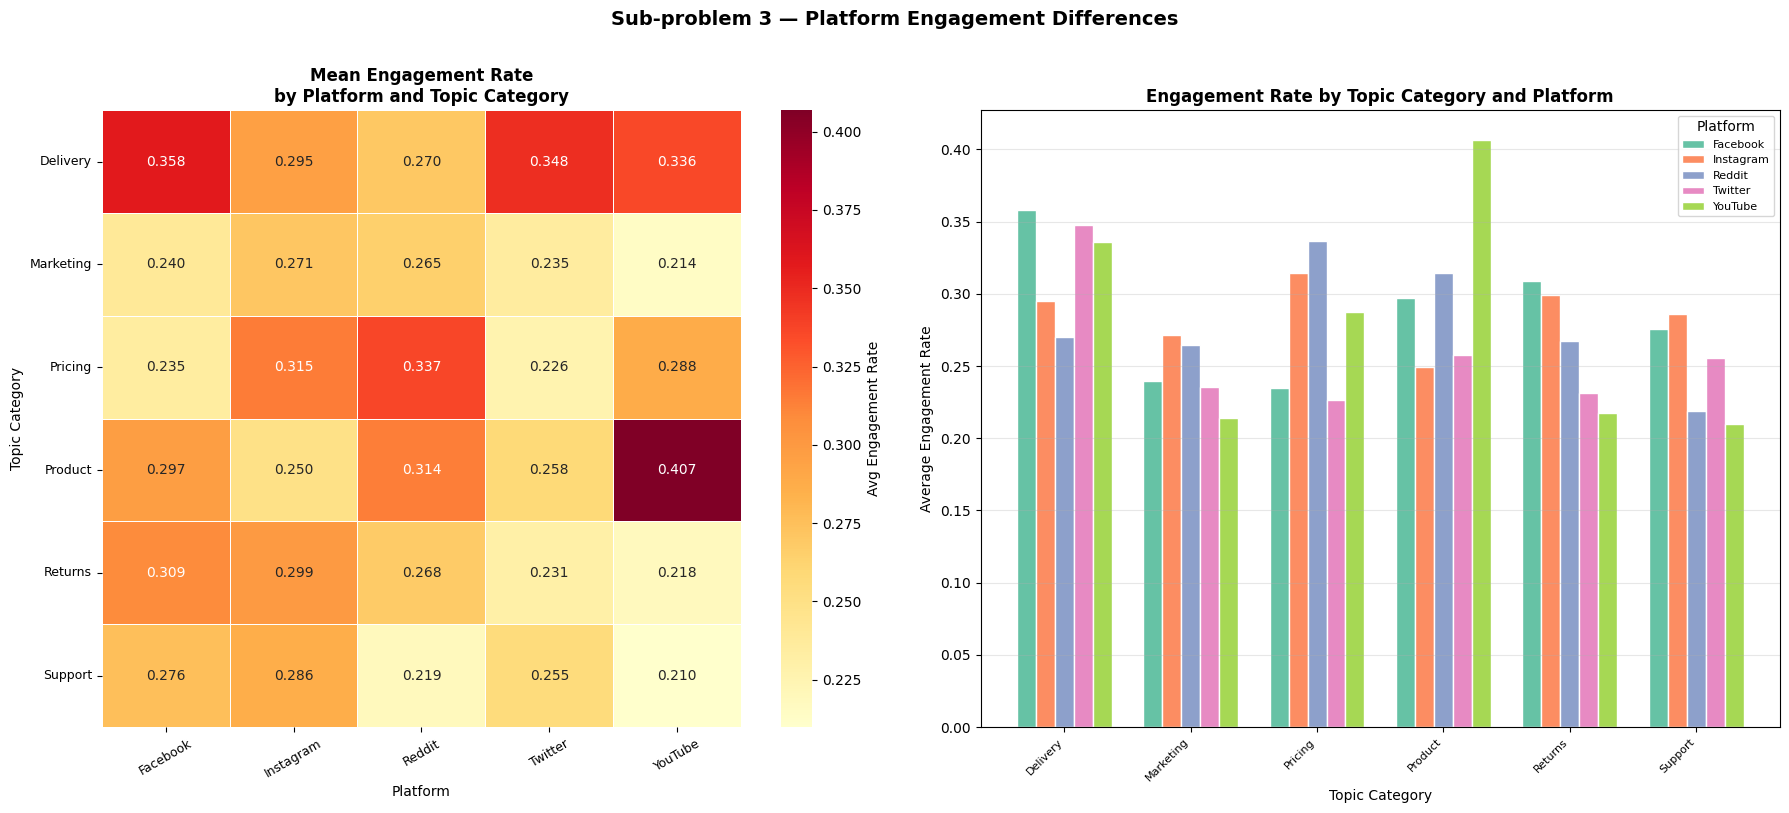

Saved: subproblem3_platform_engagement.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax1 = axes[0]
sns.heatmap(platform_topic_pivot,
            annot=True, fmt='.3f',
            cmap='YlOrRd',
            linewidths=0.5,
            ax=ax1,
            cbar_kws={'label': 'Avg Engagement Rate'})
ax1.set_title('Mean Engagement Rate\nby Platform and Topic Category',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Platform')
ax1.set_ylabel('Topic Category')
ax1.tick_params(axis='x', rotation=30, labelsize=9)
ax1.tick_params(axis='y', rotation=0, labelsize=9)

ax2 = axes[1]
platforms = platform_topic_pivot.columns.tolist()
topics = platform_topic_pivot.index.tolist()
x = np.arange(len(topics))
width = 0.15
colors = plt.cm.Set2.colors

for i, platform in enumerate(platforms):
    offset = (i - len(platforms) / 2) * width + width / 2
    ax2.bar(x + offset,
            platform_topic_pivot[platform],
            width=width,
            label=platform,
            color=colors[i],
            edgecolor='white')

ax2.set_title('Engagement Rate by Topic Category and Platform',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Topic Category')
ax2.set_ylabel('Average Engagement Rate')
ax2.set_xticks(x)
ax2.set_xticklabels(topics, rotation=45, ha='right', fontsize=8)
ax2.legend(title='Platform', fontsize=8)
ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle('Sub-problem 3 — Platform Engagement Differences',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('subproblem3_platform_engagement.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: subproblem3_platform_engagement.png")

In [22]:
print("=" * 60)
print("SUB-PROBLEM 3 FINDINGS — Platform Engagement Differences")
print("=" * 60)

print(f"\nOverall ANOVA: F={f_stat:.4f}, p={p_value:.4f}")
print(f"Conclusion: Platform differences are "
      f"{'statistically significant' if p_value < 0.05 else 'not statistically significant'} "
      f"overall (α = 0.05)")

print(f"\nPlatform ranking by mean engagement rate:")
for platform, mean in platform_means.items():
    print(f"  {platform:<15} {mean:.4f}")

sig_topics = []
for topic in sorted(df['topic_category'].unique()):
    topic_df = df[df['topic_category'] == topic]
    groups = [g['engagement_rate'].values for _, g in topic_df.groupby('platform')]
    if all(len(g) > 1 for g in groups):
        f, p = scipy_stats.f_oneway(*groups)
        if p < 0.05:
            sig_topics.append(topic)

if sig_topics:
    print(f"\nTopics where platform differences ARE significant (p < 0.05):")
    for t in sig_topics:
        print(f"  {t}")
else:
    print(f"\nNo individual topic categories showed significant "
          f"platform differences (p < 0.05)")

SUB-PROBLEM 3 FINDINGS — Platform Engagement Differences

Overall ANOVA: F=0.2293, p=0.9221
Conclusion: Platform differences are not statistically significant overall (α = 0.05)

Platform ranking by mean engagement rate:
  Instagram       0.2871
  Facebook        0.2864
  YouTube         0.2792
  Reddit          0.2787
  Twitter         0.2593

No individual topic categories showed significant platform differences (p < 0.05)
